# TTM4105 2026 Assignment 1

The purpose of this assignment is to enhance your understanding of the concepts introduced in the lectures via *experience based learning*. The assignment has three parts:

* **Part 1** focuses on how audio is converted into a signal (filtering, sampling, quantization).
* **Part 2** focuses on the main elements of transmitting a signal over a medium (modulation and IQ-plots).
* **Part 3** focuses on how multiple users share the medium (TDMA, FDMA, OFDM and CDMA).

**Submission guidelines:**

You should export this notebook with solved tasks as a PDF. Your submission should then contain two items:
1. A zip archive of the complete folder named *TTM4105_Assignment1_GroupX*.
2. A PDF export of the same notebook *including group number in the file name*. 

In case you need help with jupyter notebook and exporting your results, there is a file called *instructions_assignment1_TTM4105.pdf* on Canvas.   
One delivery per group is sufficient.

**Total points: 100** (Part 1: 40, Part 2: 35, Part 3: 25)


In [1]:
!pip install librosa

In [3]:
### NB! ###
# Run this box to import all necessary libraries.
# Remember to fill in your group number below before starting on your assignment.

%run -i "scripts/assignment1-init.py"

# TODO: Fill in your group number + 10000 here (e.g.: Group 18 has seed 10018)
seed = 10012


# <a id='part1'>Part 1: Filtering, Sampling and Quantization [40 points]</a>
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# <a id='1.1-filtering'>1.1 Filtering </a>
| |
|---|
| <img src="figures/filtering.png" alt="Signal Filtering Techniques" width="600"/> |
|*Source: [Wikipedia](https://en.wikipedia.org/wiki/Filter_%28signal_processing%29)* |
<a id="filtering"><p style="text-align: center;"><b>Figure 1.1: Different signal filtering methods that can be used to remove unwanted frequencies from the signal.</b></p></a>


In sound and telecommunications, filtering is an essential process for isolating specific frequency bands, removing noise and enhancing the overall quality of audio or data transmission. In order to improve communications, we need to understand how this process works and how to apply its principles properly.

## Experimenting with Filter Cutoff

A *cutoff frequency* is the frequency at which a filter starts to attenuate a signal. By adjusting the cutoff you can hear how filters reshape audio. Start by plotting the frequency domain of the provided audio clip to see which frequencies are present and at what amplitude. Note that we can have a lower and upper cutoff frecuency depending on the type of filter.

## Plot the Frequency Domain
Listen to `audio/around.wav`. Below you will find a code block with some template code for creating a frequency domain for the provided audio clip. You can use the helper code provided, or create your own function to plot the frequency domain of the audio clip. The output of the code should be used to answer questions in Part 1.1.1.


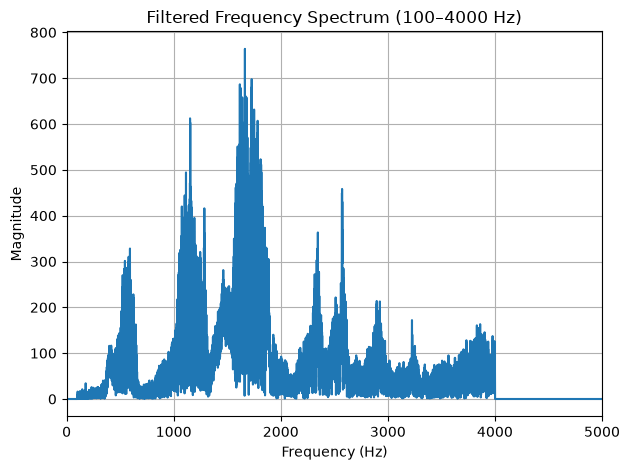

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython.display import Audio

def isolate_voice_and_drums(audio_file, sampling_rate=None):
    """
    Isolates voice and drums using a band-pass filter in the frequency domain.

    Args:
        audio_file (str): Path to the audio file.
        sampling_rate (float, optional): Sampling rate to use. If not provided, it is extracted from the file.

    Returns:
        IPython.display.Audio: Audio object for playback.
    """
    # Load audio
    signal, sr = librosa.load(audio_file, sr=sampling_rate)
    if sampling_rate is None:
        sampling_rate = sr

    # Compute FFT
    fft_spectrum = np.fft.fft(signal)
    fft_length = len(fft_spectrum)
    frequencies = np.fft.fftfreq(fft_length, d=1/sampling_rate)

    # Define band-pass filter cutoffs for voice and drums
    low_cutoff = 100    # Hz
    high_cutoff = 4000 # Hz

    # Create filter mask
    band_pass_mask = (np.abs(frequencies) >= low_cutoff) & (np.abs(frequencies) <= high_cutoff)

    # Apply the filter in frequency domain
    filtered_fft = fft_spectrum * band_pass_mask

    # Inverse FFT to reconstruct the filtered time-domain signal
    filtered_signal = np.fft.ifft(filtered_fft).real

    # Plot the magnitude spectrum of the filtered signal
    magnitude_spectrum = np.abs(filtered_fft)
    positive_freqs = frequencies[:fft_length // 2]
    positive_magnitudes = magnitude_spectrum[:fft_length // 2]

    plt.figure()
    plt.plot(positive_freqs, positive_magnitudes)
    plt.xlabel("Frequency (Hz)")
    plt.xlim(0,5000)
    plt.ylabel("Magnitude")
    plt.title("Filtered Frequency Spectrum (100–4000 Hz)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Return audio for playback
    return Audio(filtered_signal, rate=sampling_rate)

# Example usage:
isolate_voice_and_drums("audio/run-forrest.wav")

*Don't care about the warning when compiling the previous code.* <br>

Now that you have plotted the frequency domain for the audio signal, you can see the frequencies the audio clip consists of. This will be useful for the upcoming questions. Use the frequency domain acquired to answer the following questions. You can also feel free to plot a zoomed version of the spectrum, focusing on the more relevant frequencies for this audio.

## <a id='1.1.3-filtering_questions'>Filtering Questions [8 points]</a>

In the cells below you have a low-pass and a band-pass filter respectively.<br>
*Note: We highly recommend using headphones for this task.*

**Q1.1.1 [2 points]:** Referring to the **plot output** above, in which frequency range (low, mid or high) is the signal magnitude largest? <br>
*Answer:* 
The signal magnitude is the largest in mid range of frequencies (around 1500-1900Hz) with a peak at 1700Hz (magnitude of 750)

**Q1.1.2 [2 points]:** Which type of filter is appropriate for isolating just the **birds chirping**? Specify the cutoff frequency / frequencies and adjust the parameters in the cells to verify your choice. Document the result. <br>
*Answer:* A band-pass filter is the more appropriate because the birds chirping is on higher frequencies while the people talking are at lower ones.
We will start our trying around 2500 until 4000Hz (last frequency).
It works quite fine but we are still hearing a lot the girl talking. We can adjust to 2700-3800Hz, it works a bit better but not perfect. It is still attenuating most of the voice so we will keep it like that.
Result : After applying the 2700-3800Hz filter, the lower frequency ambient noise and much of the spoken voice are reduced by a lot, making the birds chirping more audible.

**Q1.1.3 [2 points]:** Which type of filter would you use to isolate the **spoken voice** while attenuating the birds and the low-frequency ambient rumble. Adjust the parameters, indicate the cutoff frequencies and document the result. <br>
*Answer:*
To isolate the spoken voice, we should also use a pass band filter to cut the lowest noisy frequencies and also cutting the highest ones. We could try something around 500-2000Hz.
It works pretty well but by adjusting to 500-2200Hz, we hear the voice more clearly.
Result : By applying the 500-2200Hz filter the low frequency noises is attenued and the higher frequency birds sounds are also reduced. The voice is still clear as we captured the part where the frequencies where the strongest.

**Q1.1.4 [2 points]:** Discuss the benefits of filtering an audio signal. What are the potential consequences of excessive or insufficient filtering?<br>
*Answer:*
Filtering is useful for removing unwanted frequency from an audio signal. It can reduce background noise, isolate voices and so make sound analysis better.
However, excessive filtering remove useful parts of the signal, like using too narrowed frequencies on a voice can make it less intelegible.
On the other hand, insufficient filtering leaves too much unwanted noises in the signal like background noises. It is making the analysis of the signal more difficult.
This is why filtering should be choosen wisely.


In [30]:
# Q1.1.2

"""
Applies a bandpass FIR filter to a WAV file.

Args:
    input_file (str): Path to the input WAV file.
    output_file (str): Path to the output filtered WAV file.
    lowcut (int, optional): Low cutoff frequency (Hz). Default 500.
    highcut (int, optional): High cutoff frequency (Hz). Default 1500.
"""

# Args (You can use your own audio file if you wish)
input_file = 'audio/run-forrest.wav'
output_file = 'audio/run-forrest-bpfiltered.wav'

# Apply filter
apply_bandpass_filter(input_file, output_file, lowcut=2700, highcut=3800)

# Import and display audio
sampling_rate, freq = sp.io.wavfile.read('audio/run-forrest-bpfiltered.wav')
ipd.Audio(freq, rate=sampling_rate)

In [31]:
# Q1.1.3

"""
Applies a bandpass FIR filter to a WAV file.

Args:
    input_file (str): Path to the input WAV file.
    output_file (str): Path to the output filtered WAV file.
    lowcut (int, optional): Low cutoff frequency (Hz). Default 500.
    highcut (int, optional): High cutoff frequency (Hz). Default 1500.
"""

# Args (You can use your own audio file if you wish)
input_file = 'audio/run-forrest.wav'
output_file = 'audio/run-forrest-bpfiltered.wav'

# Apply filter
apply_bandpass_filter(input_file, output_file, lowcut=500, highcut=2200)

# Import and display audio
sampling_rate, freq = sp.io.wavfile.read('audio/run-forrest-bpfiltered.wav')
ipd.Audio(freq, rate=sampling_rate)

# <a id='1.2-sampling'>1.2 Sampling</a>
| |
|---|
| <img src="figures/signal_sampling.png" alt="Signal Sampling" width="600"/> |
|*Source: [Wikipedia](https://en.wikipedia.org/wiki/Sampling_%28signal_processing%29)* |
<a id="fig1"><p style="text-align: center;"><b>Figure 2.1: Signal sampling representation. The continuous signal S(t) is the green line, and the discrete samples are the blue vertical lines.</b></p></a>

The image shows signal sampling, where blue vertical lines represent discrete data points from a continuous signal. Sampling discretizes the signal along the x-axis, crucial for efficient processing in digital signal processing and telecommunications, enabling analog-to-digital conversion.

## Nyquist–Shannon Sampling Theorem and Aliasing

To reconstruct a signal correctly, the Nyquist–Shannon sampling theorem states that the sampling rate must be at least twice the signal’s highest frequency component (its bandwidth). For example sound is often sampled at 44.1 kHz, and telephony at 8 kHz. Excessive sampling increases storage and computational load without adding useful information.

When a signal with frequency components above the Nyquist limit is sampled, aliasing occurs, causing higher frequencies to appear as lower frequencies due to insufficient sampling. This is shown in the figure below.

| |
|---|
| <img src="figures/aliasing.jpg" alt="Aliasing" width="600"/> |
|*Source: [ni.com docs](https://www.ni.com/docs/en-US/bundle/labwindows-cvi/page/advancedanalysisconcepts/aliasing.html)* |
<a id="fig2"><p style="text-align: center;"><b>Figure 2.2: Adequate sampling can be seen in the first graph. Aliasing due to sampling frequency lower than required by Nyquist theorem can be seen in the second graph.</b></p></a>

## <a id='1.2.1-aliasing_experimenting'>Experimenting with Aliasing [6 points]</a>

In this section you will directly observe the effects of aliasing and understand why the Nyquist limit is so important in digital signal processing.

**Use the code block below to try the following experiments:**
- Sample different frequencies below the Nyquist limit
- Sample different frequencies at or above the Nyquist limit
- Adjust the phase shift <br>

**Q1.2.0: Make sure to document results and findings in the final delivery. [6 points]** <br>
*Note: The code might result in OptimizeWarning but that does not change the outcome and can be safely ignored.*


Sampling rate: 50 Hz


c:\Users\lucie\Documents\NTNU courses\TTM4105 - Access and Transport Networks\TTM4105-assignment1-2026\TTM4105-assignment1-2026\scripts\sample_helper.py:118: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = scipy.optimize.curve_fit(sinfunc, tt, yy, p0=guess)


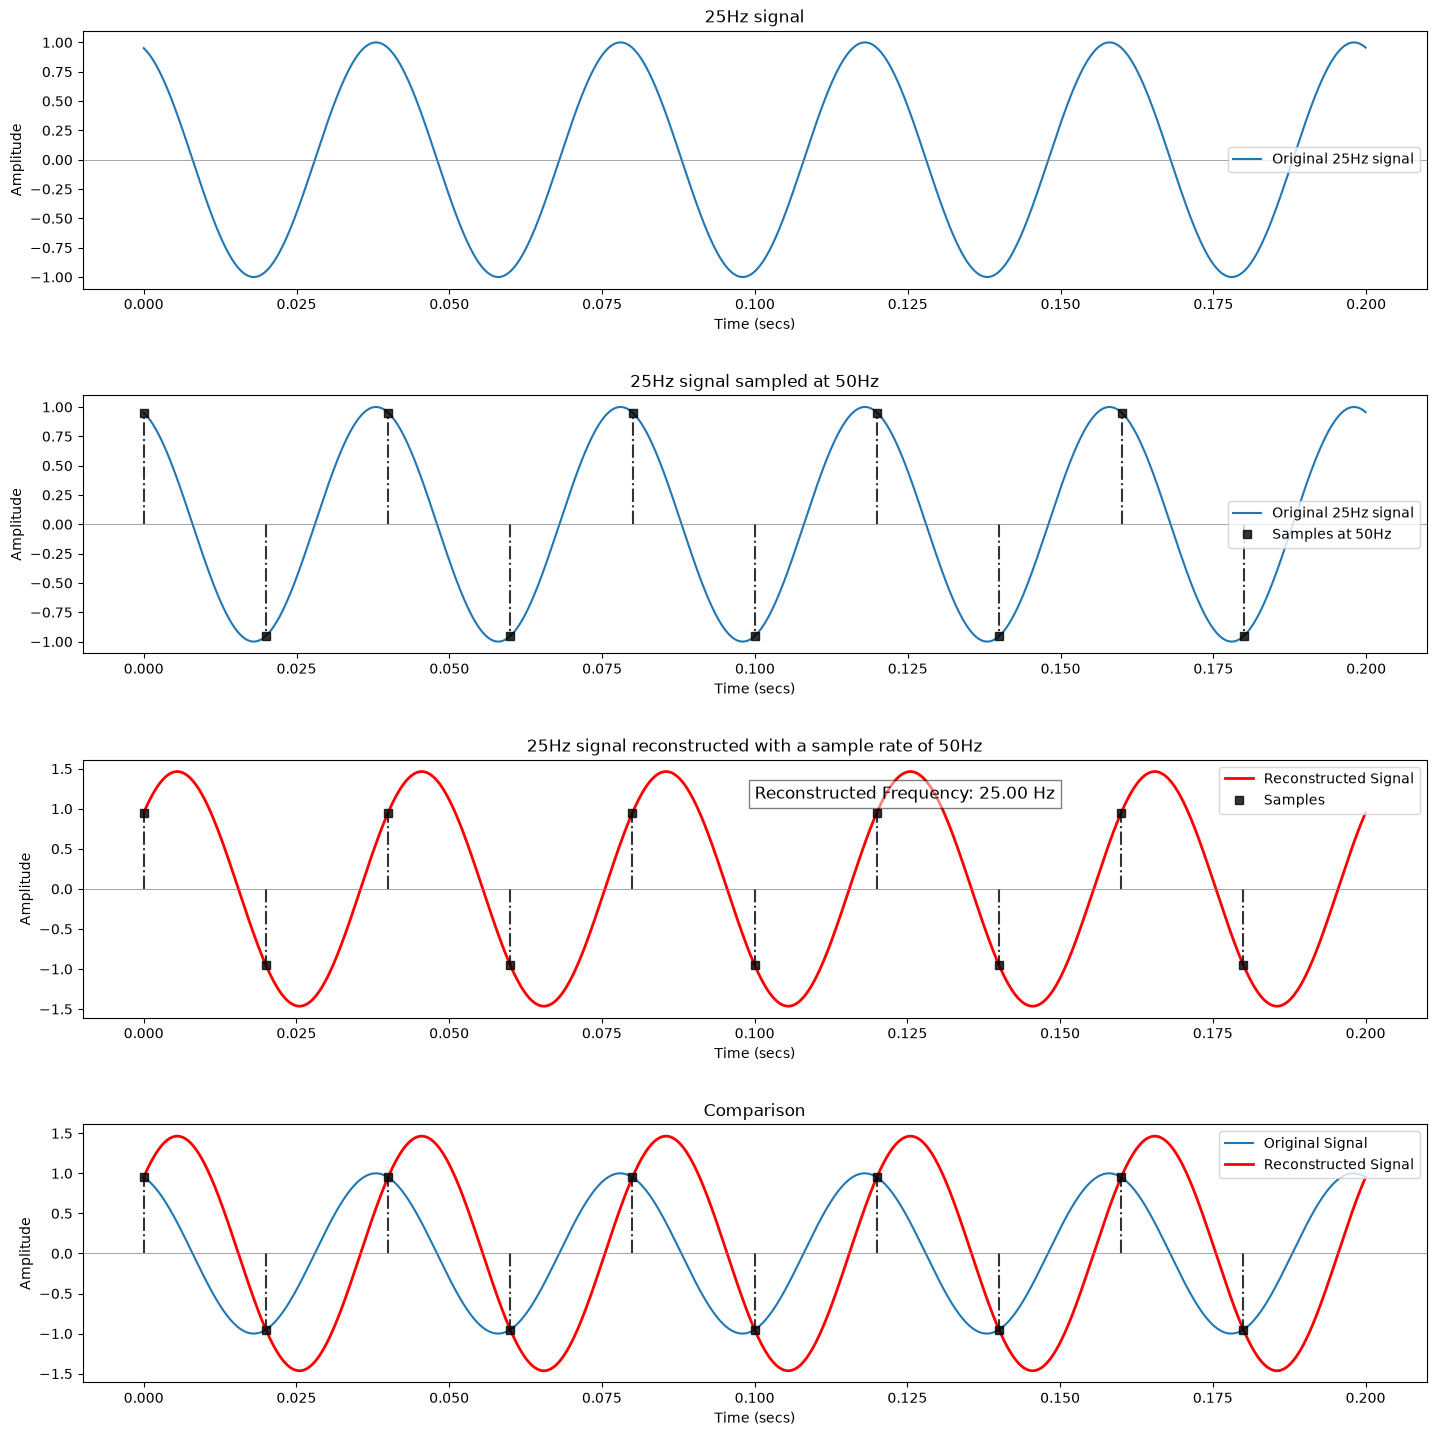

In [ ]:
"""
Args:
    frequency (int): Initial frequency (Hz).
    sample_rate (int): Sampling rate to use (Hz).
    shift_wave (int): Phase shift expressed as samples to the left.
"""

sample_frequency(frequency=25, sample_rate=50, shift_wave=120) #at nyquist limit

## <a id='1.2.4-aliasing_questions'>Aliasing Questions [4 points]</a>

**Q1.2.1 [2 points]:** Given the initial parameters (frequency = 25 Hz, sample_rate = 45 Hz, shift_wave = 120), does aliasing occur? Compare the original and reconstructed frequency.<br>
*Answer:*
Aliasing do occur because the sampling rate is below th Nyquist rate.
Nyquist requires a sampling rate of at least twice the original frequency and here 25Hz * 2 = 50Hz but 50 > 45Hz (sampling rate) so aliasing occurs.
The original is 25Hz and the reconstructed is 20.05Hz as shwon in the diagram. So the difference confirms aliasing.

**Q1.2.2 [2 points]:** Sample the signal at the Nyquist limit. What do you observe? Identify the correct information within the signal and determine which aspects require reconstruction. Show the results.<br>
*Answer:*
At the Nyquist limit, teh sampling rate is exactly twice the signal frequency. There is enough data to represent the 25Hz frequency (under the condition that the signal is band-limited and the sampling is ideal).
But we can see that we lost some of the amplitude and that the two signals (original and reconstructed) are not phased.




## <a id='1.2.6-hearing-aliasing'>Hearing Aliasing [6 points]</a>

We have an audio of a siren that has been sampled at 8 kHz (run the cell below to view and hear it). We will downsample this audio using the resample-rate parameter:

$\text{New Sample Rate} = \dfrac{\text{Original Sample Rate}}{\text{Resample Rate}}$

If the resample rate is 2, we will have the half of the samples that we had in the original. For this task we will initially set this parameter to 4, but feel free to change it and try different combinations to get more information about what is happening.

*Note: The code has a UserWarning but that does not change the outcome and can be safely ignored.*

/Users/magnusolsen/Downloads/assignment1-2026_test/scripts/sample_helper.py:249: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio_data = wav.read(input_file)
/Users/magnusolsen/Downloads/assignment1-2026_test/scripts/signal.py:449: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax_xtick_labels_strs)


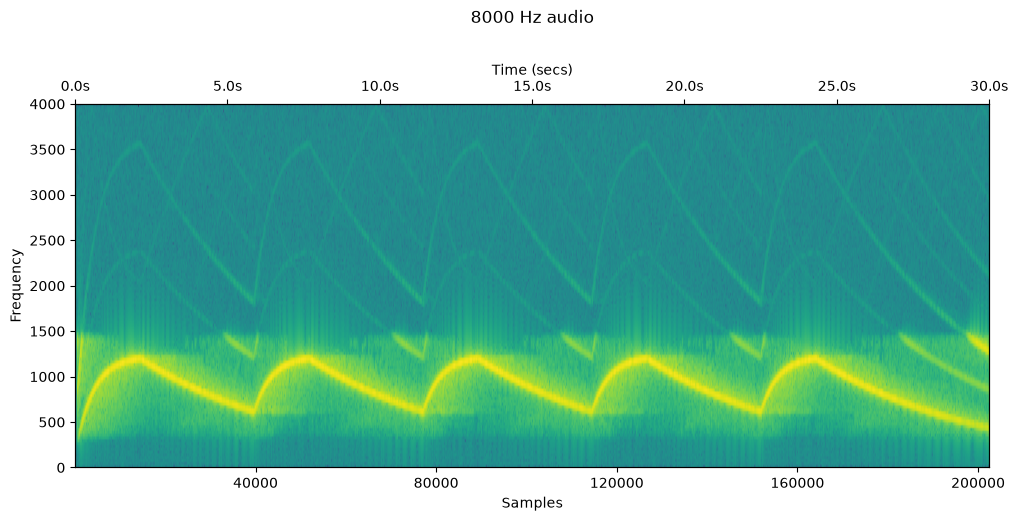

In [5]:
"""
Run this code block to display the original audio.
"""

# Args (You can use your own audio file if you wish)
input_file = 'audio/siren.wav'
output_file = 'audio/siren-filtered.wav'

# We first filter the signal for a better view
apply_bandpass_filter(input_file, output_file, lowcut=350, highcut=1400)

# Import audio
sampling_rate, freq_sweep_8000 = sp.io.wavfile.read('audio/siren-filtered.wav')

# Plot spectrogram
scripts.signal.plot_spectrogram(freq_sweep_8000, sampling_rate)

# Display audio
ipd.Audio(freq_sweep_8000, rate=sampling_rate)

Now resample the audio so we keep one sample out of three:

Sampling rate: 8000 Hz with Nyquist limit 4000 Hz
New sampling rate: 2666 Hz with Nyquist limit 888 Hz


/Users/magnusolsen/Downloads/assignment1-2026_test/scripts/signal.py:449: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax_xtick_labels_strs)


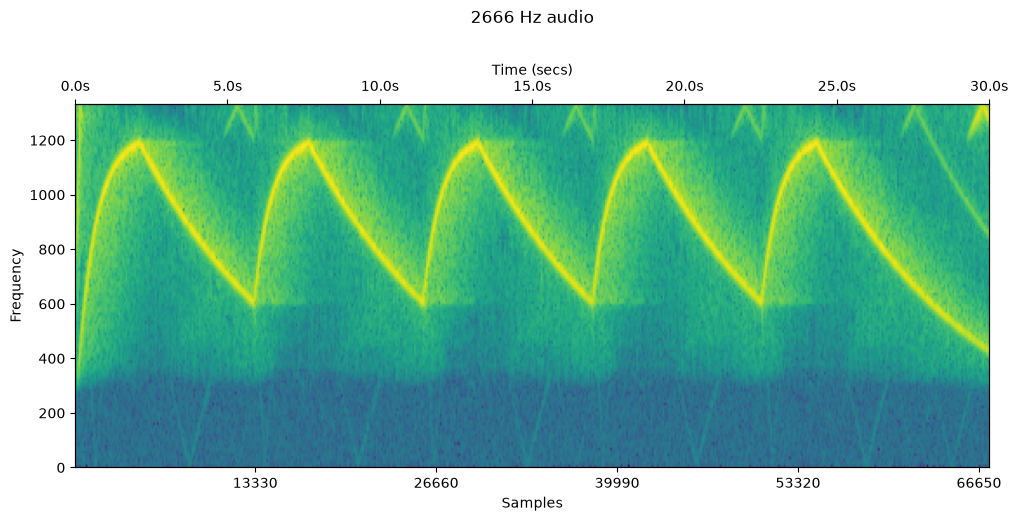

In [6]:
"""
Change the resample factor to sample the frequency sweep at lower rates.
"""
# Change this
resample_factor = 3

# Resample audio
freq_sweep_new, new_sampling_rate = scripts.signal.resample_audio(resample_factor, sampling_rate, freq_sweep_8000)

# Plot spectrogram
scripts.signal.plot_spectrogram(freq_sweep_new, new_sampling_rate)

# We interpolate the signal for being able to reproduce it
interpolated_freq, interpolated_sampling_rate = scripts.signal.interpolate_audio(freq_sweep_new, new_sampling_rate, factor=2)

# Display audio
ipd.Audio(interpolated_freq, rate=interpolated_sampling_rate)

**Q1.2.3 [3 points]:** What differences can be observed in the spectral analysis of the original and the resampled audio? <br>
*Answer:*

**Q1.2.4 [3 points]:** What auditory differences can be perceived?<br>
*Answer:*


# <a id='1.3-Quantization'>1.3 Quantization</a>

Quantization is the process of converting a continuous range of signal amplitudes into discrete levels, similar to rounding a curve to the nearest horizontal line. This reduces precision but enables digital representation. Unlike sampling, which discretizes the x-axis, quantization discretizes the y-axis. We can also have uniform and non-uniform quantization, which depends on if we have equal-sized intervals to represent signal values or not. An example of both is shown in the figure below.

| |
|---|
| <img src="figures/quantization.png" alt="Quantization" width="600"/> |
|*Source: [Tech](https://www.researchgate.net/figure/a-Mid-rise-uniform-quantization-The-mid-point-value-within-a-cell-is-taken-as-the_fig1_309083844)* |
<a id="fig5"><p style="text-align: center;"><b>Figure 3.1: Quantization schemes. (a) Mid-rise uniform quantization. The mid-point value within a cell is taken as the quantized value for a sample point falling in that cell. (b) The µ-law companding curve and its corresponding non-uniform quantization.</b></p></a>


## <a id='1.3-quantization_questions'>Quantization Questions [8 points]</a>

**Q1.3.1 [2 points]:** A signal has a peak-to-peak voltage range of 8 V and is quantized using a 14-bit linear quantizer. What is the maximum quantization error?<br>
*Answer:*

**Q1.3.2 [2 points]:** Derive a general formula for the maximum quantization error given the peak-to-peak voltage $V_{pp}$ and the number of bits $N$, assuming linear (uniform) quantization.<br>
*Answer:*

**Q1.3.3 [2 points]:** Under what circumstances is non-uniform quantization more advantageous than uniform quantization?<br>
*Answer:*

**Q1.3.4 [2 points]:**  What are the disadvantages associated with non-uniform quantization?<br>
*Answer:* 

## <a id='1.3.2-Quantization-Effects'>How does quantization affect audio signals? [8 points]</a>

Use the code block below to answer the upcoming questions. 

*Note:* In the cell below, you can run code to adjust the number of quantization bits for an audio clip. The output will include the new audio clip and two graphs. The first graph shows samples on the x-axis and their values on the y-axis. With many samples, zooming in on the x-axis can help. You can adjust the variable xlim_zoom to see a zoomed-in second graph. That works for both uniform and non-uniform quantization functions.

*Note:* The first plot and audio is uniform quantization and the second one is non-uniform quantization.

Sampling rate: 11025 Hz
Original 16-bit audio ranges from -32768 to 32767
New 4-bit audio ranges from -8 to 7
Max value: 15 Avg value: -0.06
Sampling rate: 11025 Hz
Original 16-bit audio ranges from -32768 to 32767
New 4-bit audio ranges from -8 to 7
Max value: 7 Avg value: -0.12


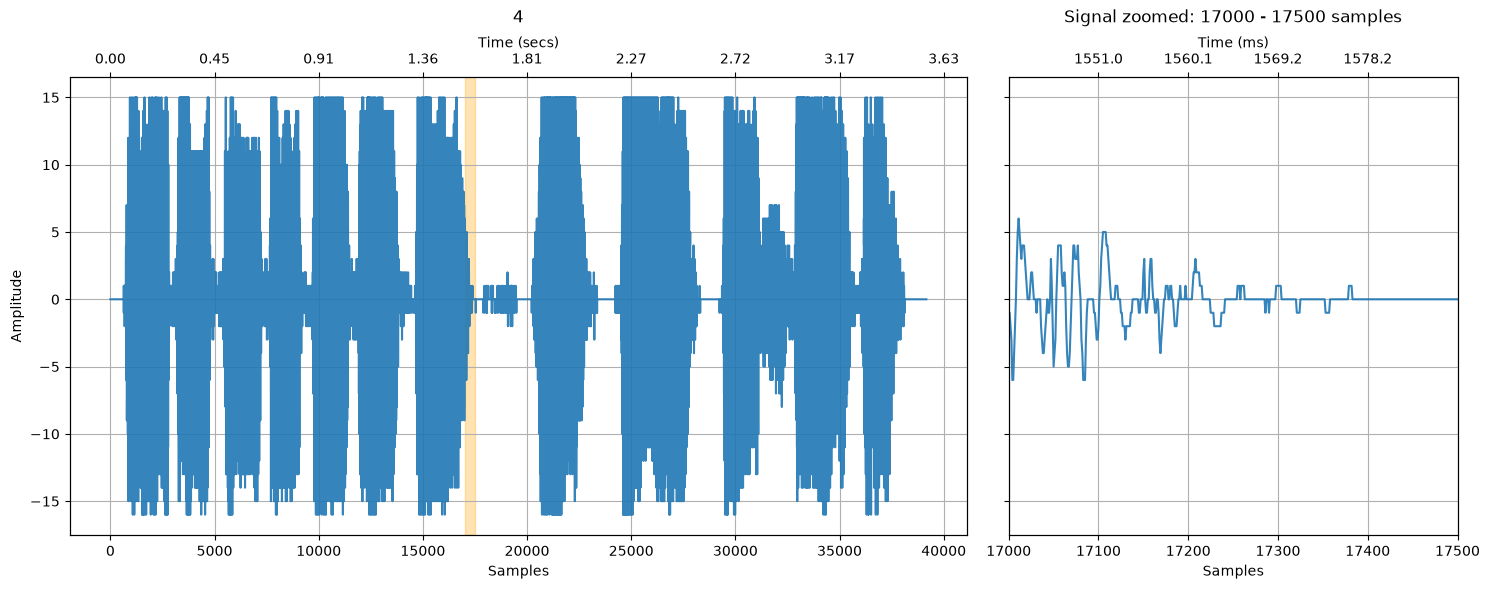

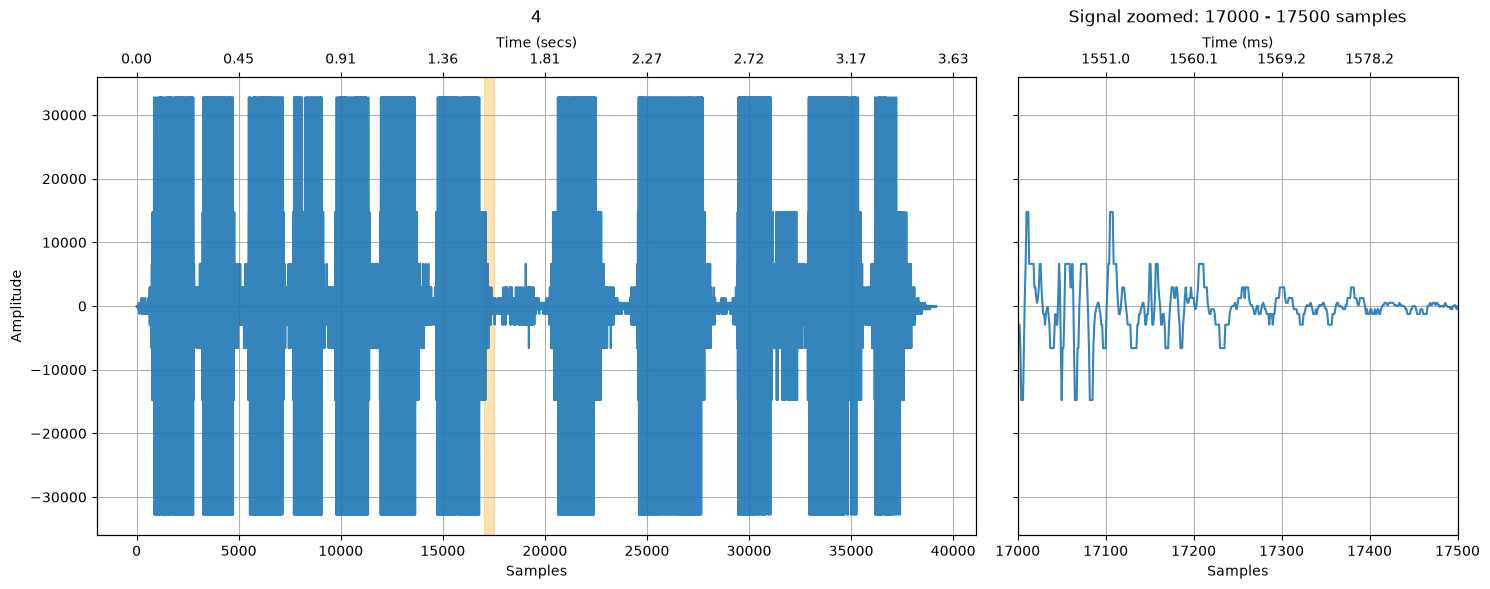

In [7]:
"""
Args:
    input_file (str): Path to the input WAV file.
    output_file (str): Path to the output filtered WAV file.
    quantization_bits (int): Amount of quantization bits.
"""

# Args (You can use your own audio file if you wish)
input_file = 'audio/blah5.wav'
output_file = 'audio/blah5_lq.wav'
output_file_nl = 'audio/blah5_nlq.wav'
quantization_bits = 4   # Change this to change the quantization bits
# Quantize signal
audio_data, sampling_rate = signal_quantization(input_file, output_file, quantization_bits=quantization_bits)

# Non-linear
nl_audio_data, nl_sampling_rate = scripts.sample_helper.signal_quantization_nonlinear(input_file, output_file_nl, quantization_bits=quantization_bits)

# Plot quantizaiton graph and non-linear quantization graph
xlim_zoom = (17000, 17500) # You may want to change this depending on what audio file you have loaded
scripts.signal.plot_signal(audio_data, sampling_rate, quantization_bits, xlim_zoom=xlim_zoom)
scripts.signal.plot_signal(nl_audio_data, nl_sampling_rate, quantization_bits, xlim_zoom=xlim_zoom)

# Import and display audio
ipd.Audio(audio_data, rate=sampling_rate)

In [ ]:
ipd.Audio(nl_audio_data, rate=sampling_rate)

**Q1.3.5 [2 points]:** Try several different values for `quantization_bits`. Present what you observe.<br>
*Answer:*

**Q1.3.6 [2 points]:** How does reducing the number of quantization levels affect the signal?<br>
*Answer:*

**Q1.3.7 [2 points]:** Identify several factors that are important when choosing the number of quantization bits.<br>
*Answer:*

**Q1.3.8 [2 points]:** Which signal type (uniform or non-uniform quantization) sounds better here? Why?<br>
*Answer:*


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# <a id='part2'>Part 2: Digital Signal Processing and Modulation [35 points]</a>
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In this section, we'll explore digital modulation and wireless symbols, focusing on using schemes like ASK, PSK, FSK, and QAM to transmit information (1's and 0's). We'll also cover IQ plots, constellations, and use Python to simulate transmissions.

## 2.1 Symbols
A symbol represents certain bits of information. The transmitted signal consists of these symbols, allowing us to convey multiple bits per symbol, thus enabling faster data transmission by manipulating wireless signals. This is why both data rate and symbol rate are used to describe communication speeds.

## 2.2 Modulation and Transmitting Bits
Modulation converts data into electrical signals for transmission. For example, binary data can be transmitted over a wire, where high and low voltage levels represent 1's and 0's, with each being a symbol. An alternating symbol signal would look like this:
| |
|---|
| <img src="figures/voltage_levels.png" alt="Voltage Levels" width="800"/> |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.1:* Electrical signal representing binary information through varying voltage levels. In the given illustration, each symbol has a set duration of 0.1 seconds, which corresponds to a single bit.</b></p></a>
 
Now let's picture that we want to transmit more information per symbol. To transmit more than one bit per symbol, an intuitive approach involves introducing additional levels to represent symbols. For instance, employing a 4-level amplitude modulation enables the transmission of 2 bits per symbol. _Figure 2.2_ shows how this can be done in practice. Note that the data conveyed in the two figures (_Figure 2.1_ and _Figure 2.2_) are not the same.

| |
|---|
| <img src="figures/4_level_shift_keying.png" alt="Several Voltage Levels" width="800"/> |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.2:* 4-level amplitude modulation scheme. This modulation scheme enables the transmission of 2 bits per symbol with a symbol duration of 0.1 seconds. This illustrates the concept of conveying multiple bits within a single symbol.</b></p></a>



## <a id='2.2-Shift keying questions'>2.2 Modulation Questions [10 points]</a>

*Note: assume a symbol duration of 0.1 s where applicable.*

**Q2.2.1 [2 points]:** How many bits per second are transmitted in figure 2.2? <br>
*Answer:*

**Q2.2.2 [3 points]:** What throughput can be achieved with **32 different amplitude levels** and **5 ns symbols**?<br>
*Answer:*

**Q2.2.3 [3 points]:** Give a general formula for bits per symbol as a function of the number of distinct symbols $M$.<br>
*Answer:*

**Q2.2.4 [2 points]:** When computing the throughput we have neglected an important real-world phenomenon. What is it, and why does it limit the practically achievable bit rate?<br>
*Answer:*

## 2.3 Wireless Symbols and Modulation
Now that we know how to send symbols over a wired medium, let's explore transmitting data wirelessly using radio waves. The principles of modulation are similar for both wired and wireless transmission, but we cannot directly send the wired square-wave signal for two reasons:

1. **Low frequencies:** Signals below 300 kHz need impractically large antennas for transmission
2. **Square waves:** These waves are inefficient as they consume too much bandwidth.

To transmit wirelessly, we use a "carrier wave," a continuous wave that carries no information on its own. We modify it, like how we adjusted voltage levels for wired transmission, to convey data.

How do we modify the carrier wave? We alter the sinusoidal carrier wave's parameters:
1. Amplitude, $A$
2. Frequency, $f$
3. Phase, $\phi$

By adjusting these, we modulate data onto the carrier wave, creating a wireless signal.


## 2.4 Amplitude Shift Keying (ASK)
Amplitude Shift Keying (ASK) is a simple digital modulation scheme where the amplitude of the carrier wave is varied to represent data. In ASK, a fixed-amplitude carrier wave at a fixed frequency is transmitted for a specific time to represent a symbol. For instance, in a 2-ASK system, the carrier is transmitted at one amplitude for a 1 and a reduced amplitude for a 0. Since only two amplitude levels are used, this is called 2-ASK. An example of 2-ASK is shown below:


| |
|---|
| <img src="https://pysdr.org/_images/ASK.svg" alt="2-ASK example" width="800"/> |
|*Source: https://pysdr.org/* |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.3:* An electrical signal and its corresponding translation into a 2-ASK scheme.</b></p></a>


But how do we create this signal digitally? Through code, we generate a vector with _N_ samples per symbol, then multiply that vector by a sinusoid. This modulates the signal onto a carrier wave (the sinusoid). The example below demonstrates 2-ASK with 10 samples per symbol:



| |
|---|
| <img src="https://pysdr.org/_images/ask3.svg" alt="Sampliong for 2-ASK" width="800"/> |
|*Source: https://pysdr.org/* |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.4:* Representation of sampling for the 2-ASK signal.</b></p></a>
---


## <a id='2.4-generatingASKsignal'>2.4 Coding Task: Generating an ASK Signal [5 points]</a>
Let's create our own ASK signal. We have provided default parameters for configuring the signal and a function that generates a binary stream of data (symbols). Your task is to create a 2-ASK signal by mixing the carrier with the symbols: when a 0 occurs, the sinusoid should have an amplitude of 0, and when a 1 occurs, the amplitude should be 1.

**NB!:** Remember to input your student number as the seed and run both code blocks to generate a random set of symbols.

In [8]:
# Carrier wave and binary waveform configuration parameters
sample_rate = 1000           # (Hz)
symbol_duration = 0.1      # (sec)
carrier_frequency = 30      # (Hz)
simulation_time = 1         # (sec)
t = np.arange(0, simulation_time, 1/sample_rate)
carrier_signal = np.sin(2*pi*carrier_frequency*t) # signal = A * sin(2πft + φ)

# Create binary stream of data
num_of_samples = sample_rate*symbol_duration
num_of_symbols = int(np.floor(np.size(t)/num_of_samples))
symbols = gen_binary_array(num_of_symbols, num_of_samples, seed)

In [9]:
# Code for ASK

# ASK waveform generation
# Modulate the generated symbol on to the carrier signal. Your signal should resemble the one shown in the picture above. 

ask_signal =   # TODO: write code here

# Binary waveform and ASK waveform Plots
figure, axis = plt.subplots(2)
# Set y-axis labels to '0' and '1'
axis[0].set_yticks([0, 1])
axis[0].set_yticklabels(['0', '1'])
axis[0].plot(t,symbols)
axis[0].set_title("Binary digital data")
axis[1].plot(t, ask_signal)
axis[1].set_title("ASK modulated signal")
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3776074209.py, line 6)

## 2.5 Frequency Shift Keying (FSK)
Next, let's explore Frequency Shift Keying (FSK). Similar to ASK, but instead of adjusting the amplitude, we adjust the frequency. We shift between _N_ frequencies, each representing a symbol. Since we are modulating a carrier, we shift the carrier frequency by +/- these _N_ values to derive the frequencies.

For example, a 4-FSK signal in the frequency domain might look like this:

| |
|---|
| <img src="https://pysdr.org/_images/fsk.svg" alt="4-FSK spectral density" width="800"/> |
|*Source: https://pysdr.org/* |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.5:* Power spectral density map of a 4-FSK signal.</b></p></a>


The figure above is a power spectral density map, showing how the power of a signal is distributed across different frequencies. The x-axis represents frequency, and the y-axis represents power density. Each peak corresponds to a specific frequency, with 4 peaks indicating a 4-FSK scheme. Variations in the rest of the spectrum represent "noise," which is electromagnetic interference from external sources.


## <a id='2.5-FSK task'>2.5 Coding Task: Generating an FSK Signal [5 points]</a>
Your task now is to generate a 2-FSK signal. Fill out the code below to generate a 2-FSK signal from the same binary stream of data. 

Start with creating a function for the frequency, mixing the binary stream of data with the carrier frequency. Then, use this to generate a sinusoid. Remember that this creates a representation of changes in the signal, and not a power spectral density. Your figure will not resemble the figure used above.

**Want a hint?**
1. Create a variable representing the different frequencies: 
    - Whenever transmitting 1's the frequency of the signal should double the carrier frequency.
    - Whenever transmitting 0's the frequency of the signal should be the same as the carrier frequency.
2. Take the binary stream of data we generated for 2-ASK earlier. Now, instead of modulating it with amplitude like before, we want to modulate it differently. Mix this data stream with the carrier frequency to get a 2-FSK signal.

In [ ]:
# Carrier wave and binary waveform configuration parameters
sample_rate = 1000 # (Hz)
symbol_duration = 0.1 # (sec)
carrier_frequency = 30 # (Hz)
simulation_time = 1 # (sec)
t = np.arange(0, simulation_time, 1/sample_rate)
carrier_signal = np.sin(2*pi*carrier_frequency*t)   # signal = A * sin(2πft + φ)

# Create binary stream of data
num_of_samples = sample_rate*symbol_duration
num_of_symbols =  int(np.floor(np.size(t)/num_of_samples))
symbols = gen_binary_array(num_of_symbols, num_of_samples, seed)

In [10]:
# FSK task
f = #TODO: write code here 
fsk_signal = #TODO: write code here 

# Binary waveform and FSK modulation waveform Plots
figure, axis = plt.subplots(2)
axis[0].plot(t, symbols)
axis[0].set_title("Binary digital data")
axis[1].plot(t, fsk_signal, 'r')
axis[1].set_title("FSK modulated signal")
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (998074114.py, line 2)

# 2.6 Phase Shift Keying (PSK)
Now let’s consider modulating the phase. We do this in a similar manner as we did with the amplitude. Again, we start with the simplest form which is Binary PSK, a.k.a. BPSK. BPSK shifts the phase of the signal between two levels of phase:

1. $\phi = 0$, leading to no phase shift of the carrier.
2. $\phi = \pi$ leading to a 180 degree phase shift of the carrier.

Below you can see an example of a BPSK scheme. Notice how the changes going from one type of symbol to another correspond to the phase shifts:

| |
|---|
| <img src="figures/bpsk_signal.png" alt="BPSK signal" width="500"/> |
|*Source: [Nikola Jovanovic, MathWorks](https://www.mathworks.com/matlabcentral/fileexchange/79224-bpsk-system-modeled-and-benchmarked-against-ber-snr)* |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.6:* Phase shifts in a BPSK signal.</b></p></a>


## <a id='2.6-PSK task'>2.6 Coding Task: Generating a PSK Signal [5 points]</a>
Generate a PSK signal. This time, mix the symbols with the phase in such a way that it aligns with the description of BPSK above. That is:
- Whenever transmitting 1's the signal wave should have no shift in phase. 
- Whenever transmitting 0's the signal wave should have a phase shift of 180 degrees.

Start by creating a formula for representing the phase. Then, use this as a variable when creating the BPSK-signal.


In [ ]:
# Carrier wave and binary waveform configuration parameters
sample_rate = 1000 # (Hz)
symbol_duration = 0.1 # (sec)
carrier_frequency = 30 # (Hz)
simulation_time = 1 # (sec)
t = np.arange(0, simulation_time, 1/sample_rate)
carrier_signal = np.sin(2*pi*carrier_frequency*t)   # signal = A * sin(2πft + φ)

# Create binary stream of data
num_of_samples = sample_rate*symbol_duration
num_of_symbols =  int(np.floor(np.size(t)/num_of_samples))
symbols = gen_binary_array(num_of_symbols, num_of_samples, seed)

In [ ]:
# PSK waveform generation
phase = 0 #TODO: write code here
bpsk_signal = 0 #TODO: write code here

# Binary waveform and PSK modulation waveform Plots
figure, axis = plt.subplots(2)
axis[0].plot(t, symbols)
axis[0].set_title("Binary digital data")
axis[1].plot(t, bpsk_signal, 'r')
axis[1].set_title("PSK modulated signal")
plt.tight_layout()
plt.show()

## 2.7 IQ-plots, constellation diagrams and QAM
Plotting a PSK signal like we did in Part 2.6 can give us an intitutive way of visualizing the phase shifts, but it can be hard to interpret such plots, especially when we use a higher level PSK modulation scheme (i.e., more than just two phase shifts). When modeling higher-level schemes, we apply an IQ-plot, as seen in figure 2.7.1:

| |
|---|
| <img src="https://pysdr.org/_images/bpsk_iq.png" alt="BPSK on an IQ-plot" width="300"/> |
|*Source: https://pysdr.org/* |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.7.1:* BPSK scheme mapped to a complex plane.</b></p></a>

For PSK we always have N different phases. We space them evenly around for best results. Each point in the plot represents a unique symbol. The distance between adjacent points corresponds to a phase shift that the signal might go through. In QPSK, the four symbols could correspond to bit patterns like 00, 01, 10, and 11 with a phase shift between them of 90°. In 8-PSK, there would be eight equally spaced points, each corresponding to a phase shift of 45°. 

Theoretically QPSK can transmit twice as much data using the same amount of bandwidth as BPSK. The tradeoff, however, is that there is less tolerance in the system for error. To illustrate this, consider that BPSK utilizes only two constellation points, dividing the entire I/Q plane into two sections along the Q-axis. Consequently, a received I/Q value could deviate by 89° yet fall within the correct decision boundary (as depicted in Fig. 2.7.3). In QPSK, the I/Q plane is divided into four sections, with decision boundaries present along both the I- and Q-axes, allowing less room for error. Therefore, in QPSK, a symbol received with a phase deviation of 89° would be misinterpreted by the receiver, resulting in a symbol error.

| |
|---|
| <img src="figures/BPSK_vs_QPSK.png" alt="Margins of error" width="500"/> |
|*Source: [NuWaves Engineering](https://nuwaves.com/wp-content/uploads/AN-005-Constellation-Diagrams-and-How-They-Are-Used1.pdf)* |
<a id="fig1"><p style="text-align: center;"><b>*Figure 2.7.3:* Comparing symbol errors .</b></p></a>

A modulation scheme that alters both the amplitude and phase is called Quadrature Amplitude Modulation (QAM). In QAM, the constellation diagram represents both amplitude and phase information. The points in the constellation are typically arranged in a rectangular grid pattern, with signal points located at various combinations of amplitude and phase. For example, in 16-QAM, there are 16 signal points arranged in a 4x4 grid. Each point in the grid represents a unique combination of both amplitude and phase, allowing for the transmission of four bits per symbol.

By adjusting both the amplitude and phase of the signal, QAM modulation schemes can achieve higher data rates and spectral efficiency compared to simpler modulation schemes like PSK or ASK.

## 2.8 Signal-To-Noise Ratios in IQ-plots
The signal to noise ratio states how well a signal is received compared to the underlying noise in a channel. The value can change and be very different based on different factors, such as transmission powers, distances, attentuation factors and local noise sources. In an IQ-plot, the noise "pushes" the received symbol in a random direction in the plot.

### 2.8.1 PSK IQ-Plot
In a PSK IQ-plot, the various angles of the plot are sectioned and mapped to the different symbol values. As a result, the increase of symbols reduces how much angle is allocated to each symbol value. The amount of angle area allocated per symbol can be given as $\frac{2\pi}{2^{bits\_per\_symbol}}$.
In the following code, you can tune the power value of a signal, as well as the average power of noise affecting a signal, to see how a PSK-signal is affected by noise.

The percentage of incorrectly received messages is 0.00%.


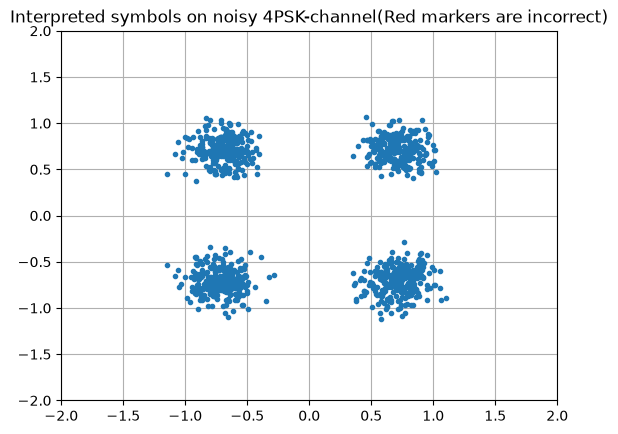

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
from scripts.iq_message_generator import message_and_noise_generation

amount_of_samples = 1024

############### 
# Edit these variables:
power = 1 # Default: 1
noise = 0.2 # Default: 0.2
bits_per_symbol = 2 # Default: 2, Must be at least 1
###############

if bits_per_symbol < 1:
    raise ValueError("bits_per_symbol must be at least 1.")

# Symbol generation
correct_messages, wrong_messages = message_and_noise_generation(bits_per_symbol, power, noise, amount_of_samples)

# Output and plotting       
print("The percentage of incorrectly received messages is {:.2f}".format(round(100*len(wrong_messages)/(len(correct_messages)+len(wrong_messages)), 2)) + "%.")
plt.plot(np.real(correct_messages),np.imag(correct_messages),'.')
plt.plot(np.real(wrong_messages),np.imag(wrong_messages),'.')
plt.title("Interpreted symbols on noisy "+ str(2**bits_per_symbol)+"PSK-channel(Red markers are incorrect)")
plt.grid(True, which='both')
plt.axis([-2*power, 2*power, -2*power, 2*power])
plt.show()

### 2.8.2 QAM IQ-Plot
In a QAM-IQ-plot, we differentiate both on amplitude and on phase. We still use the closest distance to a correct "target" point to interpret the incoming signal, but instead of only using the phase, and thereby in practice splitting the full circle of phase into pie-slices for each value, we also look at the relative amplitude of the signal.

Analyzing both phase and amplitude does introduce some complexity, in for instance, the estimation of a reference amplitude to be able to differentiate the amplitude of the incoming symbols.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
import scripts.iq_message_generator as iq

amount_of_samples = 1024

##################
# Edit these variables:
power = 1 # Default: 1
noise = 0.2 # Default: 0.2
bits_per_symbol = 2 # Must be at least 2 and divisible by 2, Default: 2
##################

# Symbol generation
if bits_per_symbol % 2 != 0 or bits_per_symbol < 2:
    raise ValueError("bits_per_symbol must be divisible by 2 and at least 2.")
target_values = iq.qam_target_generation(bits_per_symbol)
messages = iq.qam_message_generation(target_values, power, amount_of_samples)
noisy_messages = iq.qam_noise_message_generation(messages, amount_of_samples, noise)
correct_messages, wrong_messages = iq.qam_message_filter(target_values, messages, noisy_messages)

# Output and plotting       
print("The percentage of incorrectly received messages is {:.2f}".format(round(100*len(wrong_messages)/(len(correct_messages)+len(wrong_messages)), 2)) + "%.")
plt.plot(np.real(correct_messages),np.imag(correct_messages),'.')
plt.plot(np.real(wrong_messages),np.imag(wrong_messages),'.')
plt.title("Interpreted symbols on noisy "+ str(2**bits_per_symbol)+"QAM-channel(Red markers are incorrect)")
plt.grid(True, which='both')
plt.show()

## <a id='2.8-IQ-plot questions'>2.8 Questions [10 points]</a>

**Q2.8.1 [2 points]:** Given a specific modulation scheme, do all the points in a constellation diagram have to be equally spaced? Why or why not? <br>
*Answer:*

**Q2.8.2 [2 points]:** When you change the `power` and `noise` variables, how does the rate of incorrectly received messages change? Is it acceptable to tolerate any errors? Why?<br>
*Answer:*

**Q2.8.3 [3 points]:** Comparing 64-QAM with 16-QAM at the same average power, which one is more sensitive to noise? Quantify the relative spacing.<br>
*Answer:*

**Q2.8.4 [3 points]:** Why does increasing `bits_per_symbol` not always lead to higher *useful* throughput in a real channel?<br>
*Answer:*


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# <a id='part3'>Part 3: Multiple Access [25 points]</a>
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Multiple-access technologies allow several users to share a common medium by sectioning the medium along one or more *physical or logical dimensions* (time, frequency, code) and giving each user a section. This can either be done by statically through multiplexing, where each modem is allocated a dimension to use, or dynamically through multiple access technologies, where the modem is told which dimensions to use and can be dynamically changed.

Part 3 has the following structure:

* **3.1** Time-Division Multiplexing / Multiple Access
* **3.2** Frequency-Division Multiple Access
* **3.3** TDMA / FDMA Questions
* **3.4** Orthogonal Frequency-Division Multiplexing (OFDM)
* **3.5** Code-Division Multiple Access
* **3.6** Real-World Multiple Access Systems


## 3.1 Time-Division Multiplexing / Multiple Access

Time-division multiplexing works by allowing different users to use the medium at different times. Time slots are allocated to the different users, where they send their data within the time-slot. The user who owns the time-slot is allowed the full throughput of the medium, which allows for relatively high datarates when sending data, but creates the need to buffer data between sending windows.

| |
|---|
| <img src="figures/TimeDivisionMultiplexing.png" alt="Margins of error" width="500"/> |
|*Source: [Medium](https://medium.com/@boutnaru/the-networking-journey-tdm-time-division-multiplexing-ee2d0ce2d989)* |
<a id="fig1"><p style="text-align: center;"><b>*Figure 3.1.1:* Time division multiplexing.</b></p></a>

The differentiation between Multiplexing and Multiple Access technologies is between where the logic to assign and uphold time-slots is implemented. For all intents and purposes, for TDM/TDMA, the resulting behaviour is the same, but TDMA tends to allow for more dynamic allocation of time-slots. This allows high-priority senders to have multiple time-slots, when increases the priority sender's bandwidth.

### 3.1.1 TDM signal-generation
The following code-block allows you to generate a set of data-streams that are multiplexed into a TDM signal. Adjusting the `symbol_duration`, will increase or decrease the throughput of each signal.

In [ ]:
# TDM example

# Binary waveform configuration parameters (Can be changed)
symbol_duration = 0.1 # (sec) (Default: 0.1) Becomes buggy below 0.03
simulation_time = 2 # (sec) Whole integers (Default: 2)
users = 4 # Whole numbers. Default: 4

generate_tdma_signal(simulation_time, symbol_duration, users)

## 3.2 Frequency-Division Multiple Access (FDMA)

Frequency-Division Multiple Access allocates a frequency-set (subchannel) to each user, taken as a slot of the full channel's bandwidth. This allocates a portion of the total bandwidth or data-rate to each user, that it has full access to. This allows for less buffering of data, but the reduced bandwidth of each sub-channel means that only a fraction of the throughput of the total channel is allowed per user.

In [ ]:
# FDMA example

# Binary waveform configuration parameters
symbol_duration = 0.1 # (sec) Default: 0.1 Becomes buggy below 0.002
simulation_time = 2 # (sec) Whole integers. Default: 2
users = 4 # Code becomes buggy above 8. Default: 4

generate_fdma_signal(symbol_duration, simulation_time, users)

## <a id='3.3-Multiplexing Questions'>3.3 TDMA / FDMA Questions [6 points]</a>

**Q3.3.1 [2 points]:** What happens to the **per-user** bitrate when you increase the number of users in a TDMA system, and what happens to the bitrate of the **combined** signal?<br>
*Answer:* 

**Q3.3.2 [2 points]:** Why is the number of simultaneous users in an FDMA system fundamentally limited?<br>
*Answer:* 

**Q3.3.3 [2 point]:** Suggest a system that combines TDMA and FDMA, and give one real-world example.<br>
*Answer:* 


## <a id='3.4-OFDM Questions'>3.4 Orthogonal Frequency-Division Multiplexing (OFDM) [5 points]</a>

Plain FDMA wastes spectrum: each sub-carrier needs guard bands to avoid spilling into its neighbours. **OFDM** packs sub-carriers much more tightly by choosing their frequencies so that each sub-carrier is **orthogonal** to every other within the symbol time, i.e. integrating the product of any two of them over one symbol period gives zero. The price is that the receiver must be precisely aligned in frequency and time, so OFDM systems use a **cyclic prefix** to absorb timing offsets and multipath echoes.

Modern wireless systems (Wi-Fi, LTE downlink, 5G NR, DVB-T) all use OFDM (or its multi-user variant **OFDMA**) because it gets close to the spectral efficiency limit while staying easy to equalise.

Run the cell below to compare a 4-user FDMA spectrum with a 4-sub-carrier OFDM spectrum at the *same average power*. Notice how OFDM's sub-carriers can sit much closer together because their main lobes line up with their neighbours' nulls.


In [ ]:
# Self-contained OFDM-vs-FDMA visualisation
import numpy as np
import matplotlib.pyplot as plt

def compare_fdma_ofdm(users=4, sample_rate=8000, simulation_time=1.0,
                       fdma_spacing=300, ofdm_subcarrier_spacing=100,
                       seed_value=42):
    rng = np.random.default_rng(seed_value)
    t = np.arange(0, simulation_time, 1/sample_rate); n = len(t)

    # FDMA: well-separated carriers with random BPSK bits
    fdma = np.zeros(n)
    base = 500
    for u in range(users):
        bits = rng.choice([-1, 1], size=int(simulation_time/0.05))
        stream = np.repeat(bits, int(0.05*sample_rate))[:n]
        fdma += stream * np.sin(2*np.pi*(base + u*fdma_spacing)*t)

    # OFDM: tightly spaced orthogonal sub-carriers, BPSK on each
    ofdm = np.zeros(n)
    base_o = 500
    for u in range(users):
        bits = rng.choice([-1, 1], size=int(simulation_time/0.05))
        stream = np.repeat(bits, int(0.05*sample_rate))[:n]
        ofdm += stream * np.sin(2*np.pi*(base_o + u*ofdm_subcarrier_spacing)*t)

    # Spectra
    spec_f = np.abs(np.fft.rfft(fdma)); spec_o = np.abs(np.fft.rfft(ofdm))
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(freqs, spec_f)
    axes[0].set_title(f'FDMA: {users} users, spacing {fdma_spacing} Hz')
    axes[0].set_xlim(0, 2500)
    axes[0].set_ylabel('|F|')
    axes[1].plot(freqs, spec_o, color='C1')
    axes[1].set_title(f'OFDM: {users} sub-carriers, spacing {ofdm_subcarrier_spacing} Hz')
    axes[1].set_xlim(0, 2500)
    axes[1].set_xlabel('Frequency [Hz]')
    axes[1].set_ylabel('|F|')
    plt.tight_layout(); plt.show()

    print(f'Total bandwidth used by FDMA  ≈ {users*fdma_spacing} Hz')
    print(f'Total bandwidth used by OFDM ≈ {users*ofdm_subcarrier_spacing} Hz')

compare_fdma_ofdm(users=4)

**Q3.4.1 [2 points]:** Looking at the two spectra above, why does OFDM use less total bandwidth than FDMA for the same number of users at the same per-user data rate?<br>
*Answer:*

**Q3.4.2 [3 points]:** A Wi-Fi 802.11a OFDM channel is 20 MHz wide and uses 52 active sub-carriers, each 312.5 kHz apart. Compute (a) the total bandwidth occupied by the active sub-carriers, (b) the bit rate at 64-QAM with rate-3/4 forward error correction and an OFDM symbol rate of 250 000 symbols/s.<br>
*Answer:*


## 3.5 Code-Division Multiple Access (CDMA)
Code-Division multiple access uses the math to diversify different channels within the same bit-stream. This is accomplished by *chipping* each modem's data, which yields a chiprate that is higher than the original bitrate of the datastream. The chipping sequences of each user are different and specifically orthogonal. The chipped streams are then summed together and sent out on the medium. See lecture 3.

The following code block allows an approximation of how a CDMA system can be implemented based on users and symbol rate. The code will output a visualization of how the data from different users is summed together to a complete signal.

In [ ]:
# Variables for adjustment
symbol_duration = 0.1 # (sec) Default: 0.1
simulation_time = 1 # (sec) Default: 1
users = 4 # The script becomes buggy above 32. Default: 4

generate_cdma_signal(simulation_time, symbol_duration, users)

### <a id='3.5-CDMA-Questions'>CDMA Questions [6 points]</a>

**Q3.5.1 [2 point]:** What happens to the *frequency bandwidth* of a signal after it goes through chipping? (Hint: What happens when you increase the amount of users to the chipping sequence and the frequency spectrum?) <br>
*Answer:*

**Q3.5.2 [4 points]:** Two users share the channel using the chipping sequences

* Receiver A: $[1, 1]$<br>
* Receiver B: $[1, -1]$<br>

and you observe the following summed chip stream (every 2 chips encode one symbol per user, an absent user contributes 0 to that block):

$[\;2,\ 0,\ -1,\ 1,\ \ 0,\ -2,\ 1,\ 1]$

Decode the bits sent to A and B. Use **N** to mark a tuple where the user did not transmit. Show your work.<br>
*Answer:*


## <a id='3.6-Real-World-Multiple-Access'>3.6 Real-World Multiple Access Systems [8 points]</a>

A multiple-access scheme is rarely chosen in isolation. System designers pick a scheme (or combination of schemes) based on requirements such as mobility, traffic pattern, energy consumption, available bandwidth and how the channel quality varies. The four scenarios below describe real-world wireless systems. For each one:

* (a) Identify which multiple access scheme(s) it uses (TDMA, FDMA, OFDM/OFDMA, CDMA, or a hybrid).

* (b) Justify the choice with at least one concrete reason that ties back to the system's requirements.

**Q3.6.1 [2 points] — GSM voice (2G mobile):** GSM serves millions of mobile handsets with low-bit-rate, latency-sensitive voice traffic. Each base station has a fixed bandwidth allocation that it must share among many handsets while keeping handset complexity and battery use low.<br>
*Answer:*

**Q3.6.2 [2 points] — Wi-Fi (IEEE 802.11ax, 5 GHz):** Modern Wi-Fi delivers high data rates to many users sharing a 20–160 MHz channel. Devices are stationary or slow-moving, transmissions are bursty (web browsing, video streaming), and channel quality varies due to multipath inside buildings.<br>
*Answer:*

**Q3.6.3 [2 points] — GPS L1 (satellite positioning):** A GPS receiver anywhere on Earth must simultaneously receive signals from 4 or more satellites that all transmit on the same nominal carrier (1575.42 MHz). The signals arrive below the receiver's thermal noise floor, and the receiver must distinguish each satellite to perform trilateration.<br>
*Answer:*

**Q3.6.4 [2 points] — LTE downlink (4G mobile):** LTE delivers variable-rate traffic (voice, video, data) to many users with very different instantaneous channel qualities, in a 10–20 MHz channel. The base station's scheduler reallocates resources every millisecond to maximise cell throughput.<br>
*Answer:*


## Use of AI
We wish to learn about AI usage in tasks like this. Please indicate whether you have used AI to answer questions or to assist with completing the assignment. Comment on what worked, what didn't and what it was used for:

*AI-comments HERE*
